# 5.4 Exercises

## Conceptual

### 1.
Using basic statistical properties of the variance, as well as single-variable calculus, derive (5.6). In other words, prove that $\alpha$ given by (5.6) does indeed minimize $Var(\alpha X + (1 - \alpha) Y)$


$$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}, \tag{5.6}$$

$$\hat{\alpha} = \frac{\hat{\sigma}_Y^2 - \hat{\sigma}_{XY}}{\hat{\sigma}_X^2 + \hat{\sigma}_Y^2 - 2\hat{\sigma}_{XY}}. \tag{5.7}$$



<img src="images for notes/ex5_q1.png" width="600">

## 2. 
We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

(a) What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.

<span style="color:blue"> There are n points, so the chance of it not being in the sample is n-1/n. n-1 = number of points that arent the jth observation, and n = total number of observations</span>

(b) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

<span style="color:blue"> Well we dont use pidgeonhole principle here as its sampling **with replacement**. Ergo odds are same thing to the power of 2: (n-1/n)^2</span>

(c) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.

<span style="color:blue"> The value is (n-1/n)^n. We can reorganize this into $(1 - \frac{1}{n})^2$. The reason its (n-1/n)^n is because the odds of any particular observation of the bootstrap being the jth observation of the sample is (n-1/n). Each bootstrap obersvation has an equal chance, so we just power it by n. Etc etc this is ez./span>

(c) When n = 5, what is the probability that the *j*th observation is in the bootstrap sample?

<span style="color:blue"> 1-(4/5)^5/span>

In [1]:
1-(0.8**5)

0.6723199999999999

(e) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?

In [2]:
1-(0.99**100)

0.6339676587267709

(f) When n = 10, 000, what is the probability that the jth observation
is in the bootstrap sample?

In [3]:
# Lets take from the answersheets thinking and make a function for it:
def is_in_bootstrap(n):
    answer = 1-(
        ((n-1)/n)**n
    )
    return answer

is_in_bootstrap(10000)

0.6321389535670295

(g) Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

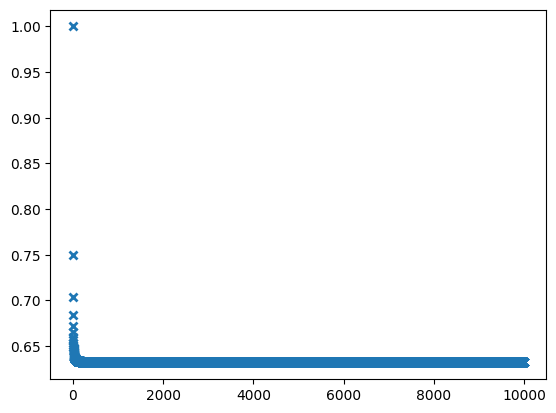

In [5]:
X = []
Y = []

for i in range(1,10001):
    X.append(i)
    Y.append(is_in_bootstrap(i))


fig, ax = plt.subplots()

ax.plot(X, Y, 'x', markeredgewidth=2)

<span style="color:blue"> the proportion of data that appear at least once in the bootstrap seems to converge to 0.63 or something similar as you approach larger samples./span>

(h) We will now investigate numerically the probability that a bootstrap
sample of size n = 100 contains the jth observation. Here
j = 4. We first create an array store with values that will subsequently
be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we record
whether or not the fifth observation is contained in the bootstrap
sample.

In [6]:
rng = np.random.default_rng (10)
store = np.empty (10000)
for i in range (10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0
#> 0
np.mean(store)

np.float64(0.6362)

## 3. 
We now review k-fold cross-validation.

(a) Explain how k-fold cross-validation is implemented.

<span style="color:blue"> Lets see if I rember: Split the data into k different groups. Iterate for each of the k groups, wlog do this with ith group: (1) Build model with all the data except the data in the ith group. Validate how the model explains the data with the ith group as a validation set. Obtain this value (MSE?), and save it. Repeat this for the other k-1 groups, obtaining each of their respective values (MSEs?). Then average them to see the fit of the model. Do this for different levels of flexibility. /span>

(b) What are the advantages and disadvantages of k-fold crossvalidation
relative to:
i. The validation set approach?
    <span style="color:blue"> Its computationally easy. Since we are testing the actual model we will end up using, what we say will be unbiased. However, we have trained the model on less data, so it will have a higher variance in terms of well everything, and this variance is like a LOT bigger. /span>
ii. LOOCV?
    <span style="color:blue">Advantage: Its lower bias than k-fold cross validation (assuming k < n). It will be the same each time we calculate it with the same datapoints, theres no question as to how to partition the data. However, its higher variance than k-fold cross validation (assuming k < n), and its also computationally very expensive. /span>
    

## 4. 
Suppose that we use some statistical learning method to make a prediction
for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.Ok

In [7]:
# Now we import the stuff for the applied section:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data
from ISLP import confusion_table
from ISLP.models import (ModelSpec as MS,
summarize ,
poly)
from sklearn.model_selection import train_test_split
import random

In [8]:
# and we import some more (probably) needed stuff
from functools import partial
from sklearn.model_selection import \
(cross_validate ,
KFold ,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

## 5
In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.

#### (a) 
Fit a logistic regression model that uses income and balance to predict default


In [9]:
# We load the data
Default = load_data('Default')
Default.head()
np.random.seed(19571)

In [10]:
# We make the model
predictors_5a = Default.columns.drop(['default', 'student'])

design_5a = MS(predictors_5a)

X_5a = design_5a.fit_transform(Default)

Y_5a = Default.default == 'Yes'
glm_5a = sm.GLM(Y_5a,
                X_5a,
                family=sm.families.Binomial())

results_5a = glm_5a.fit()
summarize(results_5a)

,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
balance,0.005600,0.000000,24.835,0.0
income,0.000021,0.000005,4.174,0.0


### (b) 
Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

#### i. 
Split the sample set into a training set and a validation set.


In [11]:
Default_train, Default_test = train_test_split(Default, test_size = 0.3, random_state = 1)
Default_train

,default,student,balance,income
2228,No,Yes,1371.468372,24248.551962
5910,No,No,0.000000,22827.184490
1950,No,No,708.579795,21728.820197
2119,No,No,1031.044588,38199.046792
5947,No,No,279.116876,30144.432505
...,...,...,...,...
2895,No,Yes,1270.092810,16809.006452
7813,Yes,No,1598.020831,39163.361056
905,No,No,1234.476479,31313.374575
5192,No,No,0.000000,29322.631394


In [12]:
Default_test

,default,student,balance,income
9953,No,Yes,776.544280,14229.728124
3850,No,No,1014.599104,51438.710199
4962,No,No,681.693576,33327.113035
3886,No,Yes,969.898685,17940.119127
5437,No,Yes,1577.083581,15230.820600
...,...,...,...,...
5273,No,No,1010.279513,34188.984649
8014,No,No,146.365857,44666.932301
8984,No,No,102.469863,44600.431974
6498,No,Yes,453.929799,12665.306995


#### ii. 
Fit a multiple logistic regression model using only the training
observations.

In [13]:
# What do they mean by a "Multiple logistic regression model"? Oh thats just logistic regression with more than one predictor. Eazy peazy.
predictors_5bi = Default_train.columns.drop(['default', 'student'])
design_5bi = MS(predictors_5bi)
X_5bi = design_5bi.fit_transform(Default_train)
Y_5bi = Default_train.default == 'Yes'

glm_5bi = sm.GLM(Y_5bi,
                X_5bi,
                family=sm.families.Binomial())

results_5bi = glm_5bi.fit()
summarize(results_5bi)

,coef,std err,z,P>|z|
intercept,-11.858100,0.528000,-22.477,0.0
balance,0.005900,0.000000,21.078,0.0
income,0.000022,0.000006,3.707,0.0


### iii.
Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.

In [14]:
# Well in our case we called Default_validation Default_train, but it shouldnt make a difference.
X_5bi_test = design_5bi.transform(Default_test)
Y_5bi_test = Default_test['default']
valid_pred_5bi = results_5bi.predict(X_5bi_test)

#valid_pred_5bi.sort_values(ascending=True)
#valid_pred_5bi_test = valid_pred_5bi.to_frame
#valid_pred_5bi_test

#a = [1,3,2,1,5]
#b = 0
#c = 0

# for i in range(0,len(valid_pred_5bi)):
#     if b < valid_pred_5bi.iloc[i]:
#         b = max(b, valid_pred_5bi.iloc[i])
#         c = i
#         print(c)
#         print(b)


# valid_pred_5bi.iloc[30]
# len(valid_pred_5bi)
valid_pred_5bi

9953    0.000919
3850    0.008410
4962    0.000806
3886    0.003090
5437    0.092877
          ...   
5273    0.005604
8014    0.000045
8984    0.000035
6498    0.000134
6327    0.110901
Length: 3000, dtype: float64

In [15]:
# So thats an assignation, but we are missing the actual assignments. I want a confusion matrix here.
labels_train_5bi = np.array(['No']*len(Default_test), dtype=object)
labels_train_5bi[valid_pred_5bi>0.5]='Yes'

labels_train_5bi_df = pd.Series(labels_train_5bi)
type(labels_train_5bi_df)
labels_train_5bi_df.unique()
#type(labels_train_5bi_df[0])

array(['No', 'Yes'], dtype=object)

In [16]:
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [17]:
Default_test['default']

9953    No
3850    No
4962    No
3886    No
5437    No
        ..
5273    No
8014    No
8984    No
6498    No
6327    No
Name: default, Length: 3000, dtype: category
Categories (2, object): ['No', 'Yes']

In [18]:
#from ISLP import confusion_table
a = confusion_table(labels_train_5bi , Default_test.default)

a.iloc[0,0]

np.int64(2893)

#### (iv) 
Compute the validation set error, which is the fraction of observations in the validation set that are misclassified:

In [19]:
(16+58)/3000

0.024666666666666667

(c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on  the results obtained.

In [20]:
# # Task where we make a function? Maybe. Here is all of part(b) but put in one area:
# Default_train, Default_test = train_test_split(Default, test_size = 0.3, random_state = 1)

# #
# predictors_5bi = Default_train.columns.drop(['default', 'student'])
# design_5bi = MS(predictors_5bi)
# X_5bi = design_5bi.fit_transform(Default_train)
# Y_5bi = Default_train.default == 'Yes'

# glm_5bi = sm.GLM(Y_5bi,
#                 X_5bi,
#                 family=sm.families.Binomial())

# results_5bi = glm_5bi.fit()
# summarize(results_5bi)

# #
# X_5bi_test = design_5bi.transform(Default_test)
# Y_5bi_test = Default_test['default']
# valid_pred_5bi = results_5bi.predict(X_5bi_test)

# #
# labels_train_5bi = np.array(['No']*len(Default_test), dtype=object)
# labels_train_5bi[valid_pred_5bi>0.5]='Yes'

# labels_train_5bi_df = pd.Series(labels_train_5bi)

# #
# confusion_table(labels_train_5bi , Default_test.default)

# # Ok lets make this a function:


In [21]:
def default_split_set(dataset, drop_columns_list, validation_size, response_var, random_state_var=1, response_value='Yes', response_other='No'):
    # We split the data up into a training and a validation set
    dataset_train, dataset_validate = train_test_split(dataset, test_size = validation_size, random_state=random_state_var)

    #response_var = 'default'
    # We train the model
    predictors_ss = dataset_train.columns.drop(drop_columns_list)
    design_ss = MS(predictors_ss)
    X_ss = design_ss.fit_transform(dataset_train)
    Y_ss = dataset_train[response_var] == response_value

    glm_ss = sm.GLM(Y_ss,
                    X_ss,
                    family=sm.families.Binomial())
    results_ss = glm_ss.fit()

    # Get the prediction using the model
    X_ss_test = design_ss.transform(dataset_validate)
    Y_ss_test = dataset_validate[response_var]
    valid_pred_ss = results_ss.predict(X_ss_test)

    # Fit the model using the X_test data
    labels_train_ss = np.array([response_other]*len(dataset_validate), dtype=object)
    labels_train_ss[valid_pred_ss>0.5]=response_value
    labels_train_ss_df = pd.Series(labels_train_ss)

    confusion_table_answer = confusion_table(labels_train_ss, dataset_validate[str(response_var)])

    number_of_correct = confusion_table_answer.iloc[0,1] + confusion_table_answer.iloc[1,0]
    number_of_total = len(dataset_validate)

    proportion_of_incorrect = number_of_correct / number_of_total
    return proportion_of_incorrect
    
default_split_set(dataset=Default, drop_columns_list = ['default', 'student'], validation_size=0.3, response_var='default')

np.float64(0.024666666666666667)

In [22]:
print('For 0.3 as validation size, the proportion of incorrect data is: '
      +
      str(default_split_set(dataset=Default, drop_columns_list = ['default', 'student'], validation_size=0.3, response_var='default', random_state_var=1))
     )

print('For 0.3 as validation size with a different random state (2), the proportion of incorrect data is: '
      +
      str(default_split_set(dataset=Default, drop_columns_list = ['default', 'student'], validation_size=0.3, response_var='default', random_state_var=2))
     )

print('For 0.3 as validation size with a different random state (3), the proportion of incorrect data is: '
      +
      str(default_split_set(dataset=Default, drop_columns_list = ['default', 'student'], validation_size=0.3, response_var='default', random_state_var=3))
     )

print('For 0.3 as validation size with a different random state (4), the proportion of incorrect data is: '
      +
      str(default_split_set(dataset=Default, drop_columns_list = ['default', 'student'], validation_size=0.3, response_var='default', random_state_var=4))
     )

For 0.3 as validation size, the proportion of incorrect data is: 0.024666666666666667
For 0.3 as validation size with a different random state (2), the proportion of incorrect data is: 0.023666666666666666
For 0.3 as validation size with a different random state (3), the proportion of incorrect data is: 0.025
For 0.3 as validation size with a different random state (4), the proportion of incorrect data is: 0.025333333333333333


### (d) 
Now consider a logistic regression model that predicts the probability
of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation
set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [23]:
# So predictors are now, instead, income, balance and a dummy var. 
# Well we have a drop columns list, maybe all we need to do is not drop the columns
# But this might not give us a dummy var. Do we need to add that to our Default dataset? Hmmm
Default.head()
# Old column uses income and balance to predict default.
# This will instead use income, balance and student, What do they mean by "a dummy variable"? Isnt this just "Student"? the column?
# Urgh, well lets see what happens if we run the function while not dropping student, without converting student to a binary
print('For 0.3 as validation size, while only dropping response from X, the proportion of incorrect data is: '
      +
      str(default_split_set(dataset=Default, drop_columns_list = ['default'], validation_size=0.3, response_var='default', random_state_var=1))
     )

# Ok thats the right proportion, but we want to see the results model.
# Lets do that without this function:

For 0.3 as validation size, while only dropping response from X, the proportion of incorrect data is: 0.024333333333333332


In [24]:
drop_columns_list = ['default']
dataset=Default
validation_size=0.3
response_var='default'
random_state_var=1
response_value='Yes'
response_other='No'

# Here starts ye old function
dataset_train, dataset_validate = train_test_split(dataset, test_size = validation_size, random_state=random_state_var)

predictors_ss = dataset_train.columns.drop(drop_columns_list)
design_ss = MS(predictors_ss)
X_ss = design_ss.fit_transform(dataset_train)
Y_ss = dataset_train[response_var] == response_value

glm_ss = sm.GLM(Y_ss,
                X_ss,
                family=sm.families.Binomial())
results_ss = glm_ss.fit()

# Get the prediction using the model
X_ss_test = design_ss.transform(dataset_validate)
Y_ss_test = dataset_validate[response_var]
valid_pred_ss = results_ss.predict(X_ss_test)

# Fit the model using the X_test data
labels_train_ss = np.array([response_other]*len(dataset_validate), dtype=object)
labels_train_ss[valid_pred_ss>0.5]=response_value
labels_train_ss_df = pd.Series(labels_train_ss)

confusion_table_answer = confusion_table(labels_train_ss, dataset_validate[str(response_var)])

summarize(results_ss)

,coef,std err,z,P>|z|
intercept,-11.142800,0.59400,-18.743,0.000
student[Yes],-0.683600,0.28000,-2.440,0.015
balance,0.005900,0.00000,21.022,0.000
income,0.000004,0.00001,0.367,0.713


## 6. 
We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coefficients
in two different ways: (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis.

### (a) 
Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.

In [25]:
#Ah I see, we need to only use income and balance as predictors. So lets remake the model for question 6:
drop_columns_list = ['default', 'student']
dataset=Default
validation_size=0.3
response_var='default'
random_state_var=1 # We follow what the answer sheet people are doing in their chosen random_state_var.
response_value='Yes'
response_other='No'

# Here starts ye old function
dataset_train, dataset_validate = train_test_split(dataset, test_size = validation_size, random_state=random_state_var)

predictors_ss = dataset_train.columns.drop(drop_columns_list)
design_ss = MS(predictors_ss)
X_ss = design_ss.fit_transform(dataset_train)
Y_ss = dataset_train[response_var] == response_value

glm_ss = sm.GLM(Y_ss,
                X_ss,
                family=sm.families.Binomial())
results_ss = glm_ss.fit()

# Get the prediction using the model
X_ss_test = design_ss.transform(dataset_validate)
Y_ss_test = dataset_validate[response_var]
valid_pred_ss = results_ss.predict(X_ss_test)

# Fit the model using the X_test data
labels_train_ss = np.array([response_other]*len(dataset_validate), dtype=object)
labels_train_ss[valid_pred_ss>0.5]=response_value
labels_train_ss_df = pd.Series(labels_train_ss)

confusion_table_answer = confusion_table(labels_train_ss, dataset_validate[str(response_var)])

summarize(results_ss)

,coef,std err,z,P>|z|
intercept,-11.858100,0.528000,-22.477,0.0
balance,0.005900,0.000000,21.078,0.0
income,0.000022,0.000006,3.707,0.0


In [26]:
results_ss.bse # Now this one was just "read the answers and copy, idk why std error and the beta standard error are different (bse), they should be the same in terms
# of what they are approximating towards.

intercept    0.527555
balance      0.000278
income       0.000006
dtype: float64

### (b) 
Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

In [27]:
def boot_fn(Dataset, drop_columns_list, response_var, response_value = 'Yes'):
    predictors_ss = Dataset.columns.drop(drop_columns_list)
    design_ss = MS(predictors_ss)
    X_ss = design_ss.fit_transform(Dataset)
    Y_ss = Dataset[response_var] == response_value
    glm_ss = sm.GLM(Y_ss,
                    X_ss,
                    family=sm.families.Binomial())
    results_ss = glm_ss.fit()
    return results_ss.params

queue = boot_fn(Dataset = Default, drop_columns_list = ['default', 'student'], response_var = 'default')
print('iloc0 is ' + str(queue.iloc[0]))
print(queue)
print('change here, fixed params here')

iloc0 is -11.540468449934616
intercept   -11.540468
balance       0.005647
income        0.000021
dtype: float64
change here, fixed params here


In [28]:
def boot_fn_bse(Dataset, drop_columns_list, response_var, response_value = 'Yes'):
    predictors_ss = Dataset.columns.drop(drop_columns_list)
    design_ss = MS(predictors_ss)
    X_ss = design_ss.fit_transform(Dataset)
    Y_ss = Dataset[response_var] == response_value
    glm_ss = sm.GLM(Y_ss,
                    X_ss,
                    family=sm.families.Binomial())
    results_ss = glm_ss.fit()
    return results_ss.bse

queue = boot_fn_bse(Dataset = Default, drop_columns_list = ['default', 'student'], response_var = 'default')
print('iloc0 is ' + str(queue.iloc[0]))
print(queue)
print('change here as well, BSE Here')

iloc0 is 0.43477246929537466
intercept    0.434772
balance      0.000227
income       0.000005
dtype: float64
change here as well, BSE Here


### (c) 
Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.

In [29]:
def boot_SE(func , 
            D, # D is gonna be the dataset D that we imported, that has two columns: X and Y. However, D could austencibly be any dataset. 
            # Its not EXPLICITLY said, but its not a dumb interpretation to think this is the generalized form. Idk if it is though. But if
            # thats the case, then where are we inputting arbitrary functions? In func I suppose
            parameter,
            n=None ,
            B=1000, # Variables that are input. if n is not specified, it is "None", whatever datatype THAT is
            seed=0):
    rng = np.random.default_rng(seed) # We get a generator for rng in numpy
    first_ , second_ = 0, 0 # Set dummy variables(?) to be 0 and 0.
    n = n or D.shape[0] # Need to check, but my guess is that if n = None, then n is set equal to D.shape[0]
    for _ in range(B):
        # We make a dummy dataset to use in the function. Its a copy so we don't change the original
        dummy_Dataset = D.copy()
        dummy_idx = rng.choice(D.index
           , D.shape[0] # This is meant to be lenght of Default
           , replace=True)

        # Thanks for this optimization Google Gemini:
        dummy_Dataset = D.iloc[dummy_idx]

        # Iloc[0] gives us the value for the first element of what we return, which for the intercept should be .iloc[0]
        value = func(dummy_Dataset, drop_columns_list = ['default', 'student'], response_var = 'default').iloc[parameter]
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)

In [30]:
intercept_SE = boot_SE(boot_fn,
                       Default,
                       0,
                       n=10000
                       ,B=1000)

print('asdf')

intercept_SE

asdf


np.float64(0.4356920972811343)

### (d) 
Comment on the estimated standard errors obtained using the
sm.GLM() function and using the bootstrap.

<span style="color:blue"> Its a pretty small difference, so that is good :)</span>

## 7. 
In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).

### (a)
Fit a logistic regression model that predicts *Direction* using *Lag1* and *Lag2*.

In [31]:
Weekly = load_data('Weekly')
Weekly.head()
len(Weekly)

1089

In [32]:
np.random.seed(1)

def lin_reg_model(Dataset, drop_columns_list, response_var, response_value = 'Yes'):
    predictors_ss = Dataset.columns.drop(drop_columns_list)
    design_ss = MS(predictors_ss)
    X_ss = design_ss.fit_transform(Dataset)
    Y_ss = Dataset[response_var] == response_value
    glm_ss = sm.GLM(Y_ss,
                    X_ss,
                    family=sm.families.Binomial())
    results_ss = glm_ss.fit()
    return results_ss

model_a = lin_reg_model(Weekly, ['Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction', 'Year'], 'Direction', 'Up')

summarize(model_a)

,coef,std err,z,P>|z|
intercept,0.2212,0.061,3.599,0.000
Lag1,-0.0387,0.026,-1.477,0.140
Lag2,0.0602,0.027,2.270,0.023


### (b)
Fit a logistic regression model that predicts Direction using *Lag1* and *Lag2* *using all but the first observation*

In [33]:
# Ok well I can see where this is going, its LOOCV. But the thang is we will need to do it for the ith observation, 
#ergo lets do it for observation 1 in such a way we can replace 1 with quang, whatever quang is (thats less than n).
# This website seems helpful:
#https://www.skytowner.com/explore/getting_rows_except_some_in_pandas_dataframe
# To get all rows except rows at integer index 0 and 2:
#df.drop(df.iloc[[0,2]].index)
# I should add a .clone() part if I don't want different lengths (I thinks), but checking it doesnt seem like I need to. Hmmm...

k = 0
Weekly_without_k = Weekly.drop(Weekly.iloc[[k]].index)

print(len(Weekly_without_k))
print(len(Weekly))



1088
1089


In [34]:
# Ok cool, so we need to just fit the regression again but with Weekly_without_k
model_b = lin_reg_model(Weekly_without_k, ['Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction', 'Year'], 'Direction', 'Up')

summarize(model_b)

,coef,std err,z,P>|z|
intercept,0.2232,0.061,3.630,0.000
Lag1,-0.0384,0.026,-1.466,0.143
Lag2,0.0608,0.027,2.291,0.022


## (c) 
Use the model from (b) to predict the direction of the first observation.
You can do this by predicting that the first observation
will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this
observation correctly classified?

In [35]:
# Ok we need to use the predict method, and we will need to see the actual value of the Y.
# Lets start looking into the prediction
# Also we might need this MS thingy used in the labs
from ISLP.models import (ModelSpec as MS,
summarize ,
poly)

print('done!')

done!


In [36]:
Weekly_k = Weekly.iloc[[k]]

if Weekly_k.iloc[0]['Direction'] == 'Up':
    print('true')

In [37]:
# # Maybe this methodology only works for specific models but for some reason NOT with the model we built. 
# # The one it works for is sm-OLS, and what we trained b4 was not OLS


# # Ok seems like we need to transform it to have the same format as the X used to train the data. 
# predict_k = Weekly_k.columns.drop(['Year', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction', 'Year'])

# # Ugh this seems cumbersome, surely we can just make the dataset fit the data and THEN drop the column? Lets do it the slow way first, then read the answers
# # Ok seems the order is wrong
# thingy = MS(['Direction'])
# X_predict_k = thingy.transform(Weekly_k)
# valid_pred_k = model_b.predict(X_predict_k)
# valid_pred_k

# Ok so I am keeping all of the above, basically I needed to use MS while training the model.

In [38]:
Weekly_k_attempt2 = Weekly.iloc[[0]][['Lag1', 'Lag2']]
Weekly_k_attempt2['intercept'] = 1
model_b.predict(Weekly_k_attempt2)
# the answer given is 0.545523. Ergo, it predicts the response to be 'Up'.

0    0.545523
dtype: float64

In [39]:
float(model_b.predict(Weekly_k_attempt2)) > 0.5

C:\Users\marco.valenzuela\AppData\Local\Temp\ipykernel_44780\614967512.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(model_b.predict(Weekly_k_attempt2)) > 0.5


True

In [40]:
# Now we compare to the actual value
Weekly.iloc[0]['Direction']

# Ok it predicted 'Up' but got it wrong, but thats not massively unexpected.

'Down'

### (d) 
Write a for loop from i = 1 to i = n, where n is the number of
observations in the data set, that performs each of the following
steps:

i. Fit a logistic regression model using all but the ith observation
to predict Direction using Lag1 and Lag2.

ii. Compute the posterior probability of the market moving up
for the ith observation.

iii. Use the posterior probability for the ith observation in order
to predict whether or not the market moves up.

iv. Determine whether or not an error was made in predicting
the direction for the ith observation. If an error was made,
then indicate this as a 1, and otherwise indicate it as a 0.

In [41]:

# We setup the dataset which includes an intercept preemptively
Weekly_intercept = Weekly.copy()
Weekly_intercept['intercept'] = 1

# Set up counters to see how many predictons we have
counter = 0
counter_errors = 0

# We loop only 3 times this time, to just test stuff for now
for k in range(0,len(Weekly)):
    # We get all the data without a particular value, in this case k
    Weekly_without_k = Weekly_intercept.drop(Weekly.iloc[[k]].index)

    # We use the previously working function
    model_loop = lin_reg_model(Weekly_without_k, ['Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction', 'Year', 'intercept'], 'Direction', 'Up')

    # We get the X test data for k
    Weekly_k = Weekly_intercept.iloc[[k]][['intercept', 'Lag1', 'Lag2']]

    # We test the prediction. If it is greater than 0.5, then Direction should be up. If thats right, we dont count error. Yata yata, etc etc.
    if model_loop.predict(Weekly_k).iloc[0] >= 0.5:
        if Weekly_intercept.iloc[k]['Direction'] == 'Up':
            counter += 1
        else:
            counter +=1
            counter_errors +=1
    else:
        if Weekly_intercept.iloc[k]['Direction'] == 'Up':
            counter += 1
            counter_errors +=1
        else:
            counter +=1
            
# End the loop, now just get the counters back
print('counter is ' + str(counter))
print('counter errors is ' + str(counter_errors))

counter is 1089
counter errors is 490


In [42]:
490/1089

0.44995408631772266

## (e)
Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

<span style="color:blue"> LMAO copied wrong question initially. <span>
    
<span style="color:blue"> Isnt is just 490 / 1089 as our estimate?, ergo 0.44995408631772266 ? Thats what I will go with<span>  


## 8. 
#### We will now perform cross-validation on a simulated data set.

### (a) 
Generate a simulated data set as follows:

In [43]:
# Ok
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

In [44]:
print(len(x))
print(len(y))

# n is 100.
# p = 1
# well its Y = X - 2X^2 + Epsilon
# where epsilon ~ N(0,1), and in this case X ~ N(0,1).


100
100


#### (b) 
Create a scatterplot of X against Y . Comment on what you find.

In [45]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

Text(0.5, 0.98, 'Your Main Dashboard Title')

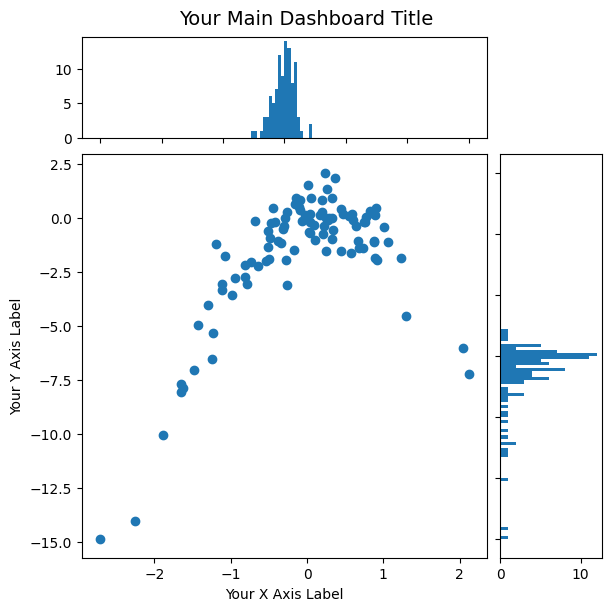

In [46]:
# plot
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='constrained'
                             )
scatter_hist(x, y, axs['scatter'], axs['histx'], axs['histy'])

# Thanks Gemini
# 1. Labels for the main scatter plot axes
axs['scatter'].set_xlabel('Your X Axis Label')
axs['axs_scatter_y'] = axs['scatter'].set_ylabel('Your Y Axis Label')

# 2. Main title for the whole mosaic dashboard
fig.suptitle('Your Main Dashboard Title', fontsize=14)

#### (c) 
Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. $Y = \beta_0 + \beta_1X + \epsilon$

ii. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \epsilon$

iii. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

iv. $Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \beta_4X^4 + \epsilon$

Note you may find it helpful to use the data.frame() function to create a single data set containing both $X$ and $Y$.  

In [47]:
# Ok we must fit some models! How? Chapter 3 easy this looks like basic linear regression. Well lets make a function for it since
# we have to do it a few times.

In [48]:
df8 = pd.DataFrame({'y': y, 'x': x, 'x^2': x**2, 'x^3':x**3, 'x^4':x**4})
df8.head()

,y,x,x^2,x^3,x^4
0,-0.544554,0.345584,0.119428,0.041273,0.014263
1,0.333950,0.821618,0.675056,0.554639,0.455701
2,-0.013532,0.330437,0.109189,0.036080,0.011922
3,-4.030442,-1.303157,1.698219,-2.213046,2.883947
4,0.484861,0.905356,0.819669,0.742092,0.671858


In [49]:
# Ok we need to get a function for LOOCV, and reuse it ideally. Lets look through previous questions:
# Well we don't have a function, but a for loop. Lets build the model with all the parameters first, check
# Then we apply LOOCV to JUST this model
# Then, we figure out how to loop the models and apply LOOCV for each of them
y8 = df8['y']
terms = df8.columns.drop('y')

x8 = MS(terms).fit_transform(df8)
model_8 = sm.OLS(y8, x8)
results_8 = model_8.fit()
summarize(results_8)

,coef,std err,t,P>|t|
intercept,0.1008,0.136,0.743,0.460
x,0.9050,0.205,4.423,0.000
x^2,-2.5059,0.221,-11.336,0.000
x^3,0.0338,0.073,0.466,0.642
x^4,0.1042,0.045,2.309,0.023


In [50]:
# Idk why I called the logistic regression model earlier 'lin_reg_model', guess I mixed them up.
def linear_reg_model(Dataset, drop_columns_list, response_var):
    # We should drop the response for this function to work
    response = Dataset[response_var]
    predictor_terms = Dataset.columns.drop(drop_columns_list)
    
    predictor = MS(predictor_terms).fit_transform(Dataset)
    model = sm.OLS(response, predictor)
    results = model.fit()
    return results

model_8c = linear_reg_model(df8, ['y', 'x^3'], ['y'])

summarize(model_8c)

# Sweet, we have a function which gives us a model

,coef,std err,t,P>|t|
intercept,0.0875,0.132,0.662,0.510
x,0.9809,0.123,7.966,0.000
x^2,-2.4663,0.203,-12.136,0.000
x^4,0.0919,0.036,2.523,0.013


In [51]:
# Now, we apply LOOCV to JUST this model:

# We make a list for the MSEs
dummy_list_MSE = []

# We setup the intercept preemptively
# Ugh this is messy, because the model returns something with an intercept and expects an intercept
# But when I try to build a model WITH an intercept, it gives me back 2 intercepts. Jolly
df8_intercept = df8.copy()
df8_intercept['intercept'] = 1


# We start with smaller range than 100 to check it works
for k in range(0, len(df8)):
    # Get all the data except the kth element.
    df8_without_k = df8.drop(df8.index[k])

    # We use a function to generate the model
    model_loop = linear_reg_model(df8, ['y', 'x^4'], ['y'])

    # We get the X test data for k
    # We will need a better way to query this guy
    df8_k = df8_intercept.iloc[[k]][['intercept', 'x', 'x^2', 'x^3']]
    #df8_k['intercept'] = 1
    
    # We test the prediction. How? MSE? Average MSE? Lets do with MSE
    k_pred = model_loop.predict(df8_k).iloc[0]
    y_test = df8_intercept.iloc[[k]][['y']]
    
    dummy_list_MSE.append(np.mean((y_test - k_pred)**2))

#summarize(model_loop)
#df8_k

np.mean(dummy_list_MSE)

np.float64(0.9718403690754165)

In [52]:
# Now we must do this for x^4, [x^4, x^3] and [x^2, x^3, x^4]. 
# Lets make a list of things to drop
drop_list = [[], ['x^4'], ['x^4', 'x^3'], ['x^2', 'x^3', 'x^4']]
drop_list2 = ['x^4']

# Ugh but how do we know which vars to generate the model with? 
# Lets try figuring this out with this stackoverflow answer:
#df8.loc[:, df8.columns.difference(drop_list[2])].head()
df8.iloc[[1]].loc[:, df8.columns.difference(drop_list[3])].head()

# Wow that looks good

,x,y
1,0.821618,0.33395


In [53]:
# So we proceed:

#create drop list:
drop_list = [['y'], ['y', 'x^4'], ['y', 'x^3', 'x^4'], ['y', 'x^2', 'x^3', 'x^4']]

# List of different MSE so we can compare them
mses_list = []


# We already made these, but I like to have everything in one run so we might as well keep this
df8_intercept = df8.copy()
df8_intercept['intercept'] = 1

for j in drop_list:

    # Need to make this each time, so it goes inside j loop
    dummy_list_MSE = []

    for k in range(0, len(df8)):

        # Get all the data except the kth element.
        df8_without_k = df8.drop(df8.index[k])
    
        # We use a function to generate the model
        #model_loop = linear_reg_model(df8, ['y', 'x^4'], ['y'])
        model_loop = linear_reg_model(df8_without_k, j, 'y')
    
        # We get the X test data for k
        # We will need a better way to query this guy
        #df8_k = df8_intercept.iloc[[k]][['intercept', 'x', 'x^2', 'x^3']]
        df8_k = df8_intercept.iloc[[k]].loc[:, df8_intercept.columns.difference(j)]
        
        # We test the prediction. How? MSE? Average MSE? Lets do with MSE
        k_pred = model_loop.predict(df8_k).iloc[0]
        y_test = df8_intercept.iloc[[k]][['y']]
        
        dummy_list_MSE.append(np.mean((y_test - k_pred)**2))
    
    mses_list.append(np.mean(dummy_list_MSE))

mses_list

[np.float64(1.3323942694179332),
 np.float64(1.3017965489358907),
 np.float64(1.1229368563419688),
 np.float64(6.633029839181983)]

(d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

<span style="color:blue"> Unless I am remaking the data, they should be identical because the way the cv is done is always the same on the same dataset.</span>

In [60]:
# we change the seed:
rng = np.random.default_rng(292)

#create drop list:
drop_list = [['y'], ['y', 'x^4'], ['y', 'x^3', 'x^4'], ['y', 'x^2', 'x^3', 'x^4']]

# List of different MSE so we can compare them
mses_list = []


# We already made these, but I like to have everything in one run so we might as well keep this
df8_intercept = df8.copy()
df8_intercept['intercept'] = 1

for j in drop_list:

    # Need to make this each time, so it goes inside j loop
    dummy_list_MSE = []

    for k in range(0, len(df8)):

        # Get all the data except the kth element.
        df8_without_k = df8.drop(df8.index[k])
    
        # We use a function to generate the model
        #model_loop = linear_reg_model(df8, ['y', 'x^4'], ['y'])
        model_loop = linear_reg_model(df8_without_k, j, 'y')
    
        # We get the X test data for k
        # We will need a better way to query this guy
        #df8_k = df8_intercept.iloc[[k]][['intercept', 'x', 'x^2', 'x^3']]
        df8_k = df8_intercept.iloc[[k]].loc[:, df8_intercept.columns.difference(j)]
        
        # We test the prediction. How? MSE? Average MSE? Lets do with MSE
        k_pred = model_loop.predict(df8_k).iloc[0]
        y_test = df8_intercept.iloc[[k]][['y']]
        
        dummy_list_MSE.append(np.mean((y_test - k_pred)**2))
    
    mses_list.append(np.mean(dummy_list_MSE))

mses_list

# We see its the same

[np.float64(1.3323942694179332),
 np.float64(1.3017965489358907),
 np.float64(1.1229368563419688),
 np.float64(6.633029839181983)]

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

<span style="color:blue"> The model with power up to 2 but no higher had the lowest average MSE in LOOCV. This fits how the data was generated, so it makesa sense. </span>

(f) Comment on the statistical significance of the coefficient estimates
that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

<span style="color:blue"> Ok we gotta redo it but now priting summaries I suppose. "Each of the models" makes sense too. But we can't just do a regular print(summarize(model)) in the loop or we will print everything. So we need to make the models again, but with all the data./span>

In [62]:
#create drop list:
drop_list = [['y'], ['y', 'x^4'], ['y', 'x^3', 'x^4'], ['y', 'x^2', 'x^3', 'x^4']]


for j in drop_list:
    model_loop = linear_reg_model(df8, j, 'y')
    print('--------')
    print('For drop list item ' + str(j) + ', the summary for the model is the following:')
    print(summarize(model_loop))
    print('--------')

    

--------
For drop list item ['y'], the summary for the model is the following:
             coef  std err       t  P>|t|
intercept  0.1008    0.136   0.743  0.460
x          0.9050    0.205   4.423  0.000
x^2       -2.5059    0.221 -11.336  0.000
x^3        0.0338    0.073   0.466  0.642
x^4        0.1042    0.045   2.309  0.023
--------
--------
For drop list item ['y', 'x^4'], the summary for the model is the following:
             coef  std err       t  P>|t|
intercept -0.0572    0.120  -0.477  0.635
x          1.1146    0.187   5.945  0.000
x^2       -2.0471    0.099 -20.673  0.000
x^3       -0.0643    0.060  -1.070  0.287
--------
--------
For drop list item ['y', 'x^3', 'x^4'], the summary for the model is the following:
             coef  std err       t  P>|t|
intercept -0.0728    0.119  -0.611  0.543
x          0.9663    0.126   7.647  0.000
x^2       -2.0047    0.091 -22.072  0.000
--------
--------
For drop list item ['y', 'x^2', 'x^3', 'x^4'], the summary for the model is 

<span style="color:blue"> For just the x, both items are statistically significant, the model is doing the best it can with what it has /<span>

<span style="color:blue"> For the x^2, its relatively close to the true values, within 0.1 in every case. The intercept its not sure if its there to a high degree, so the model gets it all right. <span>
    
<span style="color:blue"> For x^3, the model is still doing a pretty good job here surprisingly. Its not as close due to overfitting as the previous one, but the x^3 coefficients and intercept are not seen as statistically significant.<span>

<span style="color:blue"> Here in x^4 land, its pretty sure that x^3 and the intercept arent statistically significant. However, it is still using the x^4 coefficient. and the x^2 coefficient is quite far off. If we refit the model without x^3, we get this:<span>

In [66]:
#create drop list:
drop_list = [['y', 'x^3']]


for j in drop_list:
    model_loop = linear_reg_model(df8, j, ['y'])
    print('--------')
    print('For drop list item ' + str(j) + ', the summary for the model is the following:')
    print(summarize(model_loop))
    print('--------')

--------
For drop list item ['y', 'x^3'], the summary for the model is the following:
             coef  std err       t  P>|t|
intercept  0.0875    0.132   0.662  0.510
x          0.9809    0.123   7.966  0.000
x^2       -2.4663    0.203 -12.136  0.000
x^4        0.0919    0.036   2.523  0.013
--------


In [67]:
# Well uhh well uhhh uhh well uhhh I cant make model without intercept with my original function. Ehh whatever.

## 9. 
We will now consider the Boston housing data set, from the ISLP
library.

(a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimate ˆμ.

In [74]:
Boston = load_data('Boston')

print('Length Boston: ' + str(len(Boston))) # Its 506 long
np.mean(Boston[['medv']])

Length Boston: 506


np.float64(22.532806324110677)

(b) Provide an estimate of the standard error of ˆμ. Interpret this
result.
Hint: We can compute the standard error of the sample mean by
dividing the sample standard deviation by the square root of the
number of observations.

In [91]:
summation_thingy = 0
medv_mean = np.mean(Boston[['medv']])
n = len(Boston[['medv']])

for i in range(0,n):
    summation_thingy += (Boston[['medv']].iloc[i] - medv_mean)**2

np.sqrt(summation_thingy / (n-1))

medv    9.197104
Name: 0, dtype: float64

<span style="color:blue"> I take this to mean that we are pretty unsure on our estimate of the mean. Our estimate could easily be less than half the size, or almost double the size, 9 is pretty proportionally close to 22<span>

<span style="color:blue">Ok looking at the answers, I have it wrong. Maybe divide this by root n? Yep that looks right <span>

In [136]:
np.sqrt(summation_thingy / (n-1)) / (np.sqrt(n))

medv    0.408861
Name: 0, dtype: float64

(c) Now estimate the standard error of ˆμ using the bootstrap. How
does this compare to your answer from (b)?

In [141]:
list_of_means = []
B_length = 100000

for j in range(0,B_length):
    dummy_sample = Boston['medv'].sample(n=n, replace=True)
    list_of_means.append(dummy_sample.mean())

dummy_sample_std_dev = 0
mean_of_means = np.mean(list_of_means)

for k in range(0,B_length):
    dummy_sample_std_dev += (list_of_means[k] - mean_of_means)**2

boostrap_mean_se = np.sqrt(dummy_sample_std_dev / (B_length))
boostrap_mean_se
#counter

np.float64(0.4089892734818608)

<span style="color:blue"> What can I take from this? Well they are similar, but not quite the same. It seems a good estimate though, I have used a large B_length though. Also if future Marco is reading this, there was a lot of rough stuff I deleted here, it wasnt initially this neat. I had the right methodology but I wasnt using this .sample method which slowed everything down a lot.<span>

(d) Based on your bootstrap estimate from (c), provide a 95 % confidence
interval for the mean of medv. Compare it to the results
obtained by using Boston['medv'].std() and the two standard
error rule (3.9).
Hint: You can approximate a 95 % confidence interval using the
formula [ˆμ − 2SE(ˆμ), ˆμ + 2SE(ˆμ)].

In [142]:


# Bootstrap estimatg:
#medv_mean = np.mean(Boston[['medv']])
bootstrap_CI = [0,0]
bootstrap_CI[0] = medv_mean-2*(boostrap_mean_se)
bootstrap_CI[1] = medv_mean+2*(boostrap_mean_se)
bootstrap_CI

[np.float64(21.714827777146954), np.float64(23.3507848710744)]

In [147]:
calc_mean_se = Boston['medv'].std()/(np.sqrt(n))
calc_CI = [0,0]
calc_CI[0] = medv_mean-2*(calc_mean_se)
calc_CI[1] = medv_mean+2*(calc_mean_se)
calc_CI

[np.float64(21.715084029115605), np.float64(23.35052861910575)]

(e) Based on this data set, provide an estimate, ˆμmed, for the median
value of medv in the population.

In [150]:
# uhhh just this right?
Boston['medv'].median()

np.float64(21.2)

(f) We now would like to estimate the standard error of ˆμmed. Unfortunately,
there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.

In [153]:
list_of_medians = []
B_length = 10000

for j in range(0,B_length):
    dummy_sample = Boston['medv'].sample(n=n, replace=True)
    list_of_medians.append(dummy_sample.median())

dummy_sample_std_dev = 0
mean_of_medians = np.mean(list_of_medians)

for k in range(0,B_length):
    dummy_sample_std_dev += (list_of_medians[k] - mean_of_medians)**2

boostrap_median_se = np.sqrt(dummy_sample_std_dev / (B_length))
boostrap_median_se
#counter

np.float64(0.37954259415116337)

(g) Based on this data set, provide an estimate for the tenth percentile
of medv in Boston census tracts. Call this quantity ˆμ0.1.
(You can use the np.percentile() function.)

In [158]:
list_of_10th_quantile = []
B_length = 10000

for j in range(0,B_length):
    dummy_sample = Boston['medv'].sample(n=n, replace=True)
    list_of_10th_quantile.append(dummy_sample.quantile(q=0.1))

dummy_sample_std_dev = 0
mean_of_10th_quantile = np.mean(list_of_10th_quantile)

for k in range(0,B_length):
    dummy_sample_std_dev += (list_of_10th_quantile[k] - mean_of_10th_quantile)**2

boostrap_10th_quantile_se = np.sqrt(dummy_sample_std_dev / (B_length))

# Well the answer for (g) and (h) is baked in here. Lets answer (g) first:
mean_of_10th_quantile

np.float64(12.749884999999999)

(h) Use the bootstrap to estimate the standard error of μˆ0.1. Comment
on your findings.

In [159]:
# Answer for (h) now:
boostrap_10th_quantile_se

np.float64(0.5063272032737349)